<a href="https://colab.research.google.com/github/golammoula287/Thesis/blob/main/Thesis_DataSet_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install kaggle tqdm


In [33]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gmrakib2001","key":"b5df34b3ca9d05bb4919a90044a8998b"}'}

In [34]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [36]:
import os
import shutil

def download_kaggle_dataset(dataset_slug, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # download
    os.system(f"kaggle datasets download -d {dataset_slug} -p {out_dir}")

    # unzip all zips inside folder
    for file in os.listdir(out_dir):
        if file.endswith(".zip"):
            zip_path = os.path.join(out_dir, file)
            os.system(f"unzip -q {zip_path} -d {out_dir}")
            os.remove(zip_path)

    print(f" Done: {dataset_slug}")

In [37]:
download_kaggle_dataset(
    "mayankjha146025/fake-face-images-generated-from-different-gans",
    "fake_gan"
)

 Done: mayankjha146025/fake-face-images-generated-from-different-gans


In [38]:
download_kaggle_dataset(
    "mohannadaymansalah/stable-diffusion-dataaaaaaaaa",
    "stable_diffusion"
)

 Done: mohannadaymansalah/stable-diffusion-dataaaaaaaaa


In [38]:
download_kaggle_dataset(
    "awsaf49/ffhq-dataset",
    "ffhq"
)

In [39]:
import glob
import random
import os
import shutil

def sample_5k(src_dir, out_dir, limit=5000):
    os.makedirs(out_dir, exist_ok=True)

    # collect images
    exts = ["png", "jpg", "jpeg", "webp"]
    images = []

    for ext in exts:
        images.extend(glob.glob(f"{src_dir}/**/*.{ext}", recursive=True))

    random.shuffle(images)
    images = images[:limit]

    for i, img in enumerate(images):
        try:
            shutil.copy(img, f"{out_dir}/{i}.jpg")
        except:
            pass

    print(f" {out_dir}: {len(images)} images")

In [40]:
sample_5k("ffhq", "ffhq_5k", 5000)
sample_5k("fake_gan", "fake_gan_5k", 5000)
sample_5k("stable_diffusion", "stable_diffusion_5k", 5000)

 ffhq_5k: 0 images
 fake_gan_5k: 5000 images
 stable_diffusion_5k: 5000 images


In [41]:
import os

for root, dirs, files in os.walk("ffhq"):
    print(root, len(files))

In [42]:
import glob

imgs = glob.glob("ffhq/**/*.*", recursive=True)
print("Total files:", len(imgs))
print("Sample:", imgs[:10])

Total files: 0
Sample: []


In [43]:
import os

for root, dirs, files in os.walk("ffhq"):
    print("ROOT:", root)
    print("FILES:", files[:5])
    print("----")

In [44]:
!kaggle datasets download -d awsaf49/ffhq-dataset-images -p ffhq
!unzip -q ffhq/*.zip -d ffhq

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open ffhq/*.zip, ffhq/*.zip.zip or ffhq/*.zip.ZIP.

No zipfiles found.


In [45]:
!kaggle datasets download -d jessicali9530/lfw-dataset -p real_faces
!unzip -q real_faces/*.zip -d real_faces


Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:01<00:00, 109MB/s]



In [46]:
import glob, os, random, shutil

os.makedirs("real_faces_5k", exist_ok=True)

images = glob.glob("real_faces/**/*.jpg", recursive=True)

print("Total LFW images:", len(images))

random.shuffle(images)
images = images[:5000]

for i, img in enumerate(images):
    shutil.copy(img, f"real_faces_5k/{i}.jpg")

print(" Real faces 5K ready:", len(images))

Total LFW images: 13233
 Real faces 5K ready: 5000


In [47]:
import os

paths = [
    "real_faces_5k",
    "fake_gan_5k",
    "stable_diffusion_5k"
]

for p in paths:
    print(p, "->", len(os.listdir(p)) if os.path.exists(p) else " NOT FOUND")

real_faces_5k -> 5000
fake_gan_5k -> 5000
stable_diffusion_5k -> 5000


In [48]:
import glob

for p in paths:
    imgs = glob.glob(p + "/*")
    print("\n", p)
    print("Total:", len(imgs))
    print("Sample:", imgs[:3])


 real_faces_5k
Total: 5000
Sample: ['real_faces_5k/2907.jpg', 'real_faces_5k/4693.jpg', 'real_faces_5k/206.jpg']

 fake_gan_5k
Total: 5000
Sample: ['fake_gan_5k/2907.jpg', 'fake_gan_5k/4693.jpg', 'fake_gan_5k/206.jpg']

 stable_diffusion_5k
Total: 5000
Sample: ['stable_diffusion_5k/2907.jpg', 'stable_diffusion_5k/4693.jpg', 'stable_diffusion_5k/206.jpg']


In [49]:
from PIL import Image

def check_images(folder):
    bad = 0
    total = 0

    for img_path in glob.glob(folder + "/*")[:200]:  # quick check
        try:
            img = Image.open(img_path)
            img.verify()
            total += 1
        except:
            bad += 1

    print(folder, "-> OK:", total, " BAD:", bad)

for p in paths:
    check_images(p)

real_faces_5k -> OK: 200  BAD: 0
fake_gan_5k -> OK: 200  BAD: 0
stable_diffusion_5k -> OK: 200  BAD: 0


In [50]:
from PIL import Image

def check_images(folder):
    bad = 0
    total = 0

    for img_path in glob.glob(folder + "/*")[:200]:  # quick check
        try:
            img = Image.open(img_path)
            img.verify()
            total += 1
        except:
            bad += 1

    print(folder, "-> OK:", total, " BAD:", bad)

for p in paths:
    check_images(p)

real_faces_5k -> OK: 200  BAD: 0
fake_gan_5k -> OK: 200  BAD: 0
stable_diffusion_5k -> OK: 200  BAD: 0


##FINAL CONFIG CHECK

This cell verifies that all three datasets **(Real, GAN, Diffusion)** are properly loaded into the working directory. It ensures dataset integrity before performing statistical analysis. This step is essential to confirm dataset availability and avoid missing or corrupted inputs during the audit pipeline.

In [51]:
import os

DATASETS = {
    "Real": "real_faces_5k",
    "GAN": "fake_gan_5k",
    "Diffusion": "stable_diffusion_5k"
}

for k,v in DATASETS.items():
    print(k, ":", len(os.listdir(v)))

Real : 5000
GAN : 5000
Diffusion : 5000


##SAMPLING CONTROL (FOR FAIR AUDIT)

This cell performs uniform random sampling from each dataset to ensure fair comparison across classes. A fixed sample size is used to avoid bias caused by dataset size differences. This step ensures that all statistical and visual analyses are performed on equal representation from each class.

In [52]:
import glob
import random

SAMPLE_SIZE = 500

def sample(folder):
    exts = ["jpg","png","jpeg"]
    imgs = []
    for e in exts:
        imgs += glob.glob(folder + f"/**/*.{e}", recursive=True)
    random.shuffle(imgs)
    return imgs[:SAMPLE_SIZE]

data = {k: sample(v) for k,v in DATASETS.items()}

for k,v in data.items():
    print(k, len(v))

Real 500
GAN 500
Diffusion 500


##FEATURE EXTRACTION (THESIS CORE)

This is the core feature extraction stage of the dataset audit. Each image is processed to extract statistical visual features including brightness, contrast, blur (sharpness), and entropy (texture complexity). These features are used to measure distribution differences between real and AI-generated images.

In [53]:
from PIL import Image, ImageStat
import numpy as np
import cv2

def features(path):
    img = Image.open(path).convert("RGB").resize((128,128))
    stat = ImageStat.Stat(img)
    r,g,b = stat.mean

    gray = np.array(img.convert("L"))

    brightness = 0.299*r + 0.587*g + 0.114*b
    contrast = np.std([r,g,b])
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()

    hist = np.histogram(gray, bins=64, range=(0,256))[0]
    hist = hist / (hist.sum()+1e-8)
    entropy = -np.sum(hist*np.log2(hist+1e-8))

    return brightness, contrast, blur, entropy

##BUILD DATAFRAME

This cell converts extracted image features into a structured dataset (DataFrame). Each row represents one image with corresponding label and computed visual features. This format enables statistical testing and machine learning analysis.

In [54]:
import pandas as pd
from tqdm import tqdm

rows = []

for label, imgs in data.items():
    for img in tqdm(imgs, desc=label):
        try:
            b,c,bl,e = features(img)
            rows.append([label,b,c,bl,e])
        except:
            pass

df = pd.DataFrame(rows, columns=[
    "label","brightness","contrast","blur","entropy"
])

df.head()

Diffusion: 100%|██████████| 500/500 [00:21<00:00, 23.37it/s]


,label,brightness,contrast,blur,entropy
0,Real,95.829023,8.027379,973.716504,5.510204
1,Real,94.146196,9.007613,228.440871,5.233470
2,Real,93.733875,9.070583,657.620015,5.650466
3,Real,132.348533,5.278126,530.635008,5.761967
4,Real,120.357787,9.386428,1337.311562,5.620997


##CLASS BALANCE AUDIT

This cell evaluates dataset distribution across Real, GAN, and Diffusion classes. It checks whether the dataset is balanced or imbalanced. Class imbalance may introduce bias in model training and reduce classification fairness.

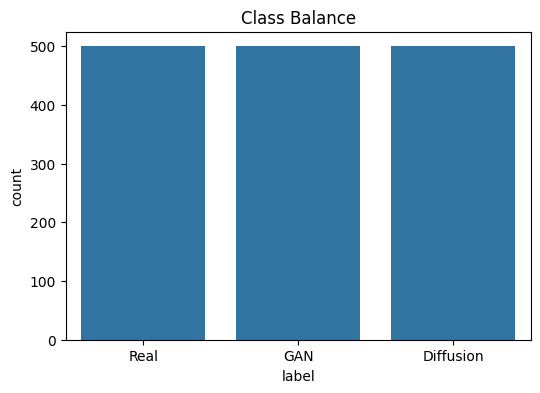

Imbalance Ratio: 1.0


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Class Balance")
plt.show()

ratio = df["label"].value_counts().max() / df["label"].value_counts().min()
print("Imbalance Ratio:", round(ratio,2))

##STATISTICAL SIGNIFICANCE

This cell applies the Kruskal-Wallis statistical test to determine whether feature distributions differ significantly across classes. It evaluates whether brightness, contrast, blur, and entropy can effectively separate real and fake images.

In [56]:
from scipy import stats

for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    stat, p = stats.kruskal(*groups)
    print(f"{col} p-value = {p:.5f}")

brightness p-value = 0.00000
contrast p-value = 0.00000
blur p-value = 0.00000
entropy p-value = 0.00000


##DISTRIBUTION PLOTS

This cell visualizes feature distributions using boxplots for brightness, contrast, blur, and entropy. It helps identify visual and statistical differences between real and synthetic image classes.

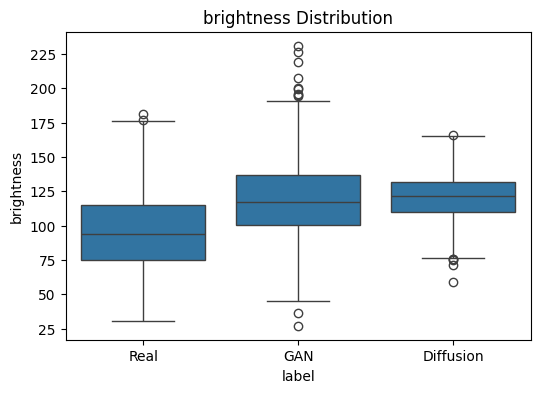

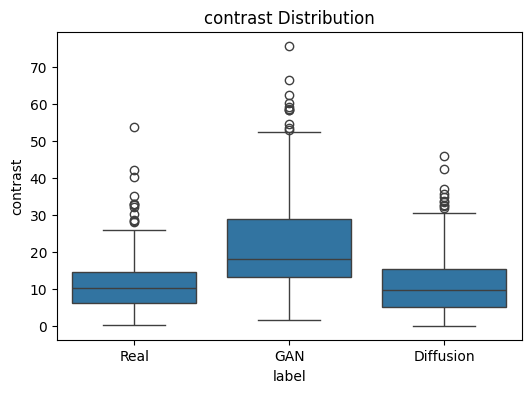

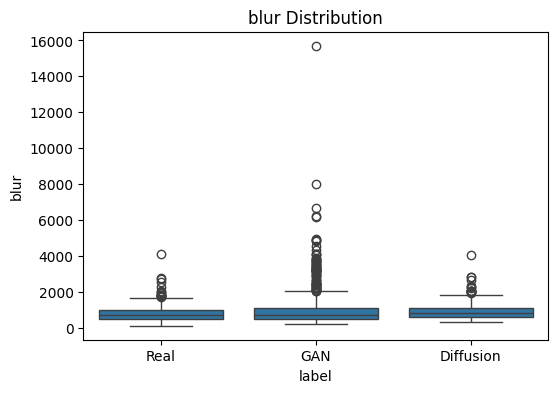

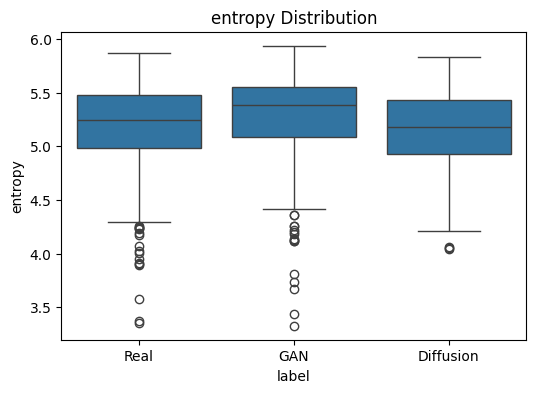

In [57]:
features = ["brightness","contrast","blur","entropy"]

for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="label", y=f)
    plt.title(f"{f} Distribution")
    plt.show()

##THESIS-READY INSIGHT GENERATOR

This cell converts statistical outputs into research-level insights. It interprets whether dataset features show meaningful separation or whether models may rely on artifacts instead of semantic differences.

In [58]:
print("\n===== THESIS INSIGHTS =====\n")

print("1. If blur differs → GAN detection shortcut risk")
print("2. If brightness differs → dataset bias risk")
print("3. If entropy differs → diffusion vs real separability")
print("4. If p-value < 0.05 → statistically separable features\n")

for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    stat, p = stats.kruskal(*groups)

    if p < 0.05:
        print(col, ": SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION")
    else:
        print(col, ": NOT SIGNIFICANT → weak feature signal")


===== THESIS INSIGHTS =====

1. If blur differs → GAN detection shortcut risk
2. If brightness differs → dataset bias risk
3. If entropy differs → diffusion vs real separability
4. If p-value < 0.05 → statistically separable features

brightness : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
contrast : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
blur : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
entropy : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION


##FINAL THESIS VERDICT SCORE

This cell computes a final Dataset Readiness Score (DRS) based on balance, statistical separability, and feature consistency. It provides a quantitative measure of whether the dataset is suitable for deepfake detection model training.

In [59]:
score = 0

# balance
ratio = df["label"].value_counts().max() / df["label"].value_counts().min()
if ratio < 1.5:
    score += 25

# stats significance
for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    _, p = stats.kruskal(*groups)
    if p < 0.05:
        score += 15

print("FINAL DATASET READINESS SCORE:", score, "/ 100")

if score >= 80:
    print(" EXCELLENT — READY FOR THESIS MODEL TRAINING")
elif score >= 60:
    print(" GOOD — NEED AUGMENTATION")
else:
    print(" NOT READY — DATASET WEAK")

FINAL DATASET READINESS SCORE: 85 / 100
 EXCELLENT — READY FOR THESIS MODEL TRAINING
